In [3]:
from pathlib import Path
import torch

SCRIPT_DIR = Path("/home/apaudel/NuGraph/scripts")
LOG_ROOT = Path("/home/apaudel/NuGraph/logs")

RUN_NAME = "merged1_July3_tpc_pds_ep45_bs64_in8_int32"
DATA_PATH = SCRIPT_DIR / "merged1_July21_40k"

# Automatically choose the newest version_N directory
version_dirs = sorted(
    (LOG_ROOT / RUN_NAME).glob("version_*"),
    key=lambda p: int(p.name.split("_")[-1])
)

if not version_dirs:
    raise FileNotFoundError(f"No version directory found for {RUN_NAME}")

VERSION_DIR = version_dirs[-1]
CKPT_DIR = VERSION_DIR / "checkpoints"

checkpoints = list(CKPT_DIR.glob("*.ckpt"))
if not checkpoints:
    raise FileNotFoundError(f"No checkpoint found in {CKPT_DIR}")

# Prefer the newest non-last.ckpt checkpoint
epoch_checkpoints = [p for p in checkpoints if p.name != "last.ckpt"]
CKPT = max(epoch_checkpoints or checkpoints, key=lambda p: p.stat().st_mtime)

PRED_H5 = SCRIPT_DIR / f"{RUN_NAME}_test_predictions.h5"

print("Run directory :", VERSION_DIR)
print("Checkpoint    :", CKPT)
print("Prediction H5 :", PRED_H5)

# Inspect saved training configuration
checkpoint_data = torch.load(CKPT, map_location="cpu", weights_only=False)
hyperparameters = checkpoint_data.get("hyper_parameters", {})

print("\nRelevant checkpoint hyperparameters:")
for key, value in hyperparameters.items():
    key_lower = key.lower()
    if any(word in key_lower for word in ["event", "opt", "interaction", "feature"]):
        print(f"  {key}: {value}")

Run directory : /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0
Checkpoint    : /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/checkpoints/epoch=44-step=21105.ckpt
Prediction H5 : /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_test_predictions.h5

Relevant checkpoint hyperparameters:
  in_features: 8
  hit_features: 128
  nexus_features: 32
  interaction_features: 32
  instance_features: 8
  ophit_features: 128
  pmt_features: 64
  flash_features: 32
  event_classes: ['cc_nue', 'es_nue']
  event_head: True
  use_optical: True


In [5]:
import subprocess
import sys

command = [
    sys.executable,
    str(SCRIPT_DIR / "test_event.py"),
    "--device", "0",
    "--data-path", "/home/apaudel/NuGraph/scripts/merged1_July21_40k",
    "--checkpoint", str(CKPT),
    "--outfile", str(PRED_H5),
    "--batch-size", "64",
    "--num-workers", "0",
]

print("Running command:\n")
print(" ".join(command))

subprocess.run(command, cwd=SCRIPT_DIR, check=True)

print("\nCreated:", PRED_H5)

Running command:

/home/apaudel/.conda/envs/nugraph-gpu/bin/python /home/apaudel/NuGraph/scripts/test_event.py --device 0 --data-path /home/apaudel/NuGraph/scripts/merged1_July21_40k --checkpoint /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/checkpoints/epoch=44-step=21105.ckpt --outfile /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_test_predictions.h5 --batch-size 64 --num-workers 0


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 1g.10gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/apaudel/.conda/envs/nugraph-gpu/lib/python3.14/site-packages/py

data path = /home/apaudel/NuGraph/scripts/merged1_July21_40k
using checkpoint = /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/checkpoints/epoch=44-step=21105.ckpt
output file = /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_test_predictions.h5
Predicting DataLoader 0: 100%|██████████| 27/27 [00:07<00:00,  3.47it/s]
inference for 1669 events is 11.20 s
event classes = ['cc_nue', 'es_nue']


100%|██████████| 27/27 [00:00<00:00, 36.09it/s]


saved: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_test_predictions.h5
        run  subrun  event  y_true  y_pred  prob_cc_nue  prob_es_nue
0  20000216     216  10797       0       0     0.958067     0.041933
1  20000394     394  39686       1       0     0.642022     0.357978
2  20000340     340  36976       1       1     0.099923     0.900077
3  20000071      71   3508       0       0     0.917749     0.082251
4  20000238     238  11873       0       0     0.905987     0.094013

counts true:
y_true
0    980
1    689
Name: count, dtype: int64

counts pred:
y_pred
0    973
1    696
Name: count, dtype: int64

Created: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_test_predictions.h5


In [7]:
import numpy as np
import pandas as pd

# Show the available pandas HDF keys
with pd.HDFStore(PRED_H5, mode="r") as store:
    print("Available HDF keys:", store.keys())

# test_event.py saves the prediction DataFrame under the "events" key
df = pd.read_hdf(PRED_H5, key="events")

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

# Truth and predicted class indices
y_true = df["y_true"].to_numpy(dtype=int)
y_pred = df["y_pred"].to_numpy(dtype=int)

# Read the class ordering from the checkpoint
event_classes = hyperparameters.get("event_classes")

if event_classes is None:
    raise KeyError("event_classes was not found in the checkpoint hyperparameters.")

event_classes = list(event_classes)

print("\nCheckpoint class ordering:")
for index, class_name in enumerate(event_classes):
    print(f"  {index}: {class_name}")

cc_idx = next(
    i for i, name in enumerate(event_classes)
    if "cc" in str(name).lower()
)

es_idx = next(
    i for i, name in enumerate(event_classes)
    if "es" in str(name).lower()
)

# Automatically locate probability columns
probability_columns = [
    column for column in df.columns
    if str(column).lower().startswith("prob")
]

print("\nProbability columns:", probability_columns)

cc_probability_column = next(
    column for column in probability_columns
    if "cc" in str(column).lower()
)

es_probability_column = next(
    column for column in probability_columns
    if "es" in str(column).lower()
)

p_cc = df[cc_probability_column].to_numpy(dtype=float)
p_es = df[es_probability_column].to_numpy(dtype=float)

# Required orientation:
#
#                  Predicted ES    Predicted CC
# True CC
# True ES
cm_counts = np.array([
    [
        np.sum((y_true == cc_idx) & (y_pred == es_idx)),
        np.sum((y_true == cc_idx) & (y_pred == cc_idx)),
    ],
    [
        np.sum((y_true == es_idx) & (y_pred == es_idx)),
        np.sum((y_true == es_idx) & (y_pred == cc_idx)),
    ],
])

cm_fraction = cm_counts / cm_counts.sum(axis=1, keepdims=True)

counts_table = pd.DataFrame(
    cm_counts,
    index=["True CC", "True ES"],
    columns=["Predicted ES", "Predicted CC"],
)

fraction_table = pd.DataFrame(
    cm_fraction,
    index=["True CC", "True ES"],
    columns=["Predicted ES", "Predicted CC"],
)

print(f"\nNumber of test events: {len(y_true)}")
print(f"Overall accuracy:       {np.mean(y_true == y_pred):.4f}")

print("\nConfusion matrix counts:")
display(counts_table)

print("\nRow-normalized confusion matrix:")
display(fraction_table.round(4))

print("\nAverage probabilities:")
print(f"True CC: average P(CC) = {p_cc[y_true == cc_idx].mean():.4f}")
print(f"True CC: average P(ES) = {p_es[y_true == cc_idx].mean():.4f}")
print(f"True ES: average P(ES) = {p_es[y_true == es_idx].mean():.4f}")
print(f"True ES: average P(CC) = {p_cc[y_true == es_idx].mean():.4f}")

Available HDF keys: ['/events']

Columns:
['run', 'subrun', 'event', 'y_true', 'y_pred', 'prob_cc_nue', 'prob_es_nue']

First five rows:


,run,subrun,event,y_true,y_pred,prob_cc_nue,prob_es_nue
0,20000216,216,10797,0,0,0.958067,0.041933
1,20000394,394,39686,1,0,0.642022,0.357978
2,20000340,340,36976,1,1,0.099923,0.900077
3,20000071,71,3508,0,0,0.917749,0.082251
4,20000238,238,11873,0,0,0.905987,0.094013



Checkpoint class ordering:
  0: cc_nue
  1: es_nue

Probability columns: ['prob_cc_nue', 'prob_es_nue']

Number of test events: 1669
Overall accuracy:       0.8029

Confusion matrix counts:


,Predicted ES,Predicted CC
True CC,168,812
True ES,528,161



Row-normalized confusion matrix:


,Predicted ES,Predicted CC
True CC,0.1714,0.8286
True ES,0.7663,0.2337



Average probabilities:
True CC: average P(CC) = 0.7231
True CC: average P(ES) = 0.2769
True ES: average P(ES) = 0.7374
True ES: average P(CC) = 0.2626


,Predicted ES,Predicted CC
True CC,168,812
True ES,528,161


,Predicted ES,Predicted CC
True CC,0.1714,0.8286
True ES,0.7663,0.2337


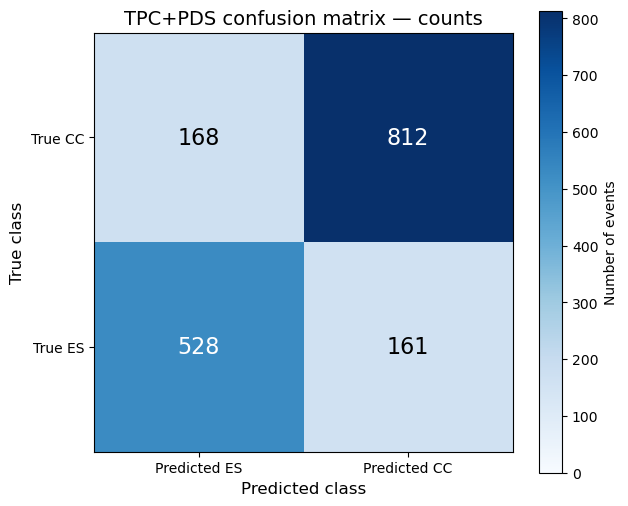

Saved: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_confusion_counts.png


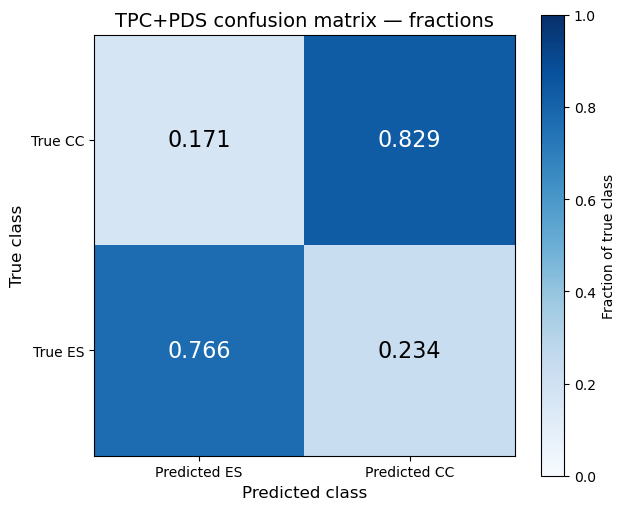

Saved: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_confusion_fraction.png


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUTPUT_DIR = Path("/home/apaudel/NuGraph/scripts")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Exact orientation requested:
#
#                  Predicted ES    Predicted CC
# True CC
# True ES

cm_counts = np.array([
    [
        np.sum((y_true == cc_idx) & (y_pred == es_idx)),
        np.sum((y_true == cc_idx) & (y_pred == cc_idx)),
    ],
    [
        np.sum((y_true == es_idx) & (y_pred == es_idx)),
        np.sum((y_true == es_idx) & (y_pred == cc_idx)),
    ],
])

cm_fraction = cm_counts / cm_counts.sum(axis=1, keepdims=True)

counts_table = pd.DataFrame(
    cm_counts,
    index=["True CC", "True ES"],
    columns=["Predicted ES", "Predicted CC"],
)

fraction_table = pd.DataFrame(
    cm_fraction,
    index=["True CC", "True ES"],
    columns=["Predicted ES", "Predicted CC"],
)

display(counts_table)
display(fraction_table.round(4))


def plot_confusion_matrix(matrix, value_format, title, output_file):
    fig, ax = plt.subplots(figsize=(6.4, 5.4))

    image = ax.imshow(
        matrix,
        cmap="Blues",
        vmin=0,
        vmax=1 if value_format == ".3f" else None,
    )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Predicted ES", "Predicted CC"])

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["True CC", "True ES"])

    ax.set_xlabel("Predicted class", fontsize=12)
    ax.set_ylabel("True class", fontsize=12)
    ax.set_title(title, fontsize=14)

    threshold = 0.5 if value_format == ".3f" else matrix.max() / 2

    for row in range(2):
        for column in range(2):
            value = matrix[row, column]

            ax.text(
                column,
                row,
                format(value, value_format),
                ha="center",
                va="center",
                fontsize=16,
                color="white" if value > threshold else "black",
            )

    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(
        "Fraction of true class"
        if value_format == ".3f"
        else "Number of events"
    )

    fig.tight_layout()
    fig.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_file)


counts_png = OUTPUT_DIR / f"{RUN_NAME}_confusion_counts.png"
fraction_png = OUTPUT_DIR / f"{RUN_NAME}_confusion_fraction.png"

plot_confusion_matrix(
    cm_counts,
    "d",
    "TPC+PDS confusion matrix — counts",
    counts_png,
)

plot_confusion_matrix(
    cm_fraction,
    ".3f",
    "TPC+PDS confusion matrix — fractions",
    fraction_png,
)

fraction_table.to_csv(
    OUTPUT_DIR / f"{RUN_NAME}_confusion_fraction.csv"
)

True CC events: 980
True ES events: 689

Average probabilities
True CC: mean P(CC) = 0.7231
True CC: mean P(ES) = 0.2769
True ES: mean P(ES) = 0.7374
True ES: mean P(CC) = 0.2626


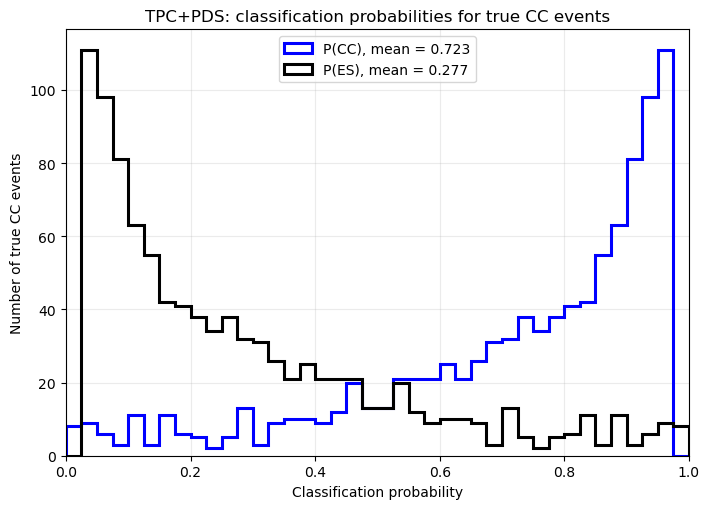

Saved: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_true_CC_probabilities.png


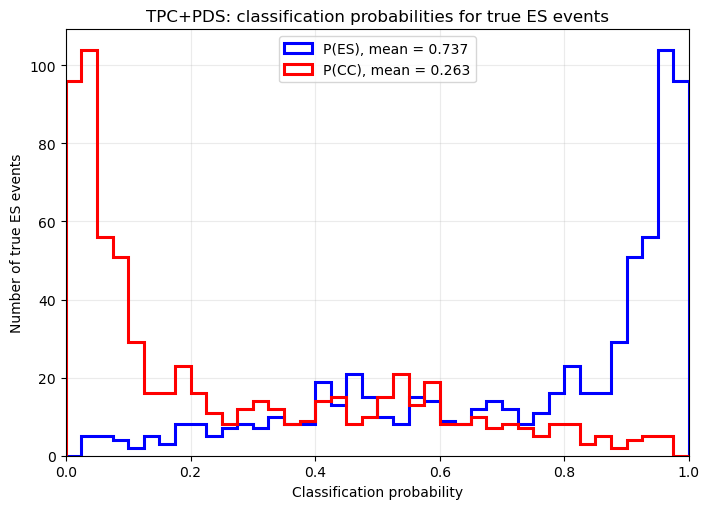

Saved: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_true_ES_probabilities.png


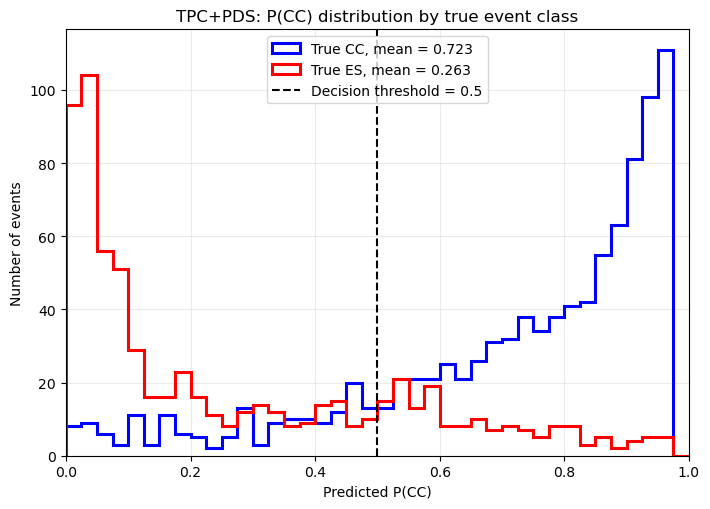

Saved: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int32_PCC_true_CC_vs_true_ES.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(0.0, 1.0, 41)

true_cc_mask = y_true == cc_idx
true_es_mask = y_true == es_idx

print("True CC events:", true_cc_mask.sum())
print("True ES events:", true_es_mask.sum())

print("\nAverage probabilities")
print(f"True CC: mean P(CC) = {p_cc[true_cc_mask].mean():.4f}")
print(f"True CC: mean P(ES) = {p_es[true_cc_mask].mean():.4f}")
print(f"True ES: mean P(ES) = {p_es[true_es_mask].mean():.4f}")
print(f"True ES: mean P(CC) = {p_cc[true_es_mask].mean():.4f}")


# ----------------------------------------------------------
# Plot 1: probabilities for true CC events
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.2, 5.2))

ax.hist(
    p_cc[true_cc_mask],
    bins=bins,
    histtype="step",
    linewidth=2.2,
    color="blue",
    label=f"P(CC), mean = {p_cc[true_cc_mask].mean():.3f}",
)

ax.hist(
    p_es[true_cc_mask],
    bins=bins,
    histtype="step",
    linewidth=2.2,
    color="black",
    label=f"P(ES), mean = {p_es[true_cc_mask].mean():.3f}",
)

ax.set_xlabel("Classification probability")
ax.set_ylabel("Number of true CC events")
ax.set_xlim(0, 1)
ax.set_title("TPC+PDS: classification probabilities for true CC events")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

true_cc_png = OUTPUT_DIR / f"{RUN_NAME}_true_CC_probabilities.png"
fig.savefig(true_cc_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", true_cc_png)


# ----------------------------------------------------------
# Plot 2: probabilities for true ES events
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.2, 5.2))

ax.hist(
    p_es[true_es_mask],
    bins=bins,
    histtype="step",
    linewidth=2.2,
    color="blue",
    label=f"P(ES), mean = {p_es[true_es_mask].mean():.3f}",
)

ax.hist(
    p_cc[true_es_mask],
    bins=bins,
    histtype="step",
    linewidth=2.2,
    color="red",
    label=f"P(CC), mean = {p_cc[true_es_mask].mean():.3f}",
)

ax.set_xlabel("Classification probability")
ax.set_ylabel("Number of true ES events")
ax.set_xlim(0, 1)
ax.set_title("TPC+PDS: classification probabilities for true ES events")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

true_es_png = OUTPUT_DIR / f"{RUN_NAME}_true_ES_probabilities.png"
fig.savefig(true_es_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", true_es_png)


# ----------------------------------------------------------
# Plot 3: P(CC) separation for both true classes
# ----------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.2, 5.2))

ax.hist(
    p_cc[true_cc_mask],
    bins=bins,
    histtype="step",
    linewidth=2.2,
    color="blue",
    label=f"True CC, mean = {p_cc[true_cc_mask].mean():.3f}",
)

ax.hist(
    p_cc[true_es_mask],
    bins=bins,
    histtype="step",
    linewidth=2.2,
    color="red",
    label=f"True ES, mean = {p_cc[true_es_mask].mean():.3f}",
)

ax.axvline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Decision threshold = 0.5",
)

ax.set_xlabel("Predicted P(CC)")
ax.set_ylabel("Number of events")
ax.set_xlim(0, 1)
ax.set_title("TPC+PDS: P(CC) distribution by true event class")
ax.legend()
ax.grid(alpha=0.25)

fig.tight_layout()

pcc_comparison_png = OUTPUT_DIR / f"{RUN_NAME}_PCC_true_CC_vs_true_ES.png"
fig.savefig(pcc_comparison_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", pcc_comparison_png)

In [10]:
from pathlib import Path
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

RUN_NAME = "merged1_July3_tpc_pds_ep45_bs64_in8_int32"

RUN_DIR = Path(
    "/home/apaudel/NuGraph/logs"
) / RUN_NAME / "version_0"

if not RUN_DIR.exists():
    raise FileNotFoundError(f"Run directory not found: {RUN_DIR}")

event_files = sorted(RUN_DIR.glob("events.out.tfevents.*"))

if not event_files:
    raise FileNotFoundError(f"No TensorBoard event file found in {RUN_DIR}")

print("Run directory:")
print(RUN_DIR)

print("\nTensorBoard event files:")
for event_file in event_files:
    print(" ", event_file.name)

ea = EventAccumulator(
    str(RUN_DIR),
    size_guidance={
        "scalars": 0,
        "images": 0,
        "histograms": 0,
        "compressedHistograms": 0,
        "tensors": 0,
    },
)

ea.Reload()
tags = ea.Tags()

print("\nScalar tags:")
for tag in tags.get("scalars", []):
    print(" ", tag)

print("\nImage tags:")
for tag in tags.get("images", []):
    print(" ", tag)

print("\nHistogram tags:")
for tag in tags.get("histograms", []):
    print(" ", tag)

Run directory:
/home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0

TensorBoard event files:
  events.out.tfevents.1784659630.jupyter-apaudel.3760.0

Scalar tags:
  lr-AdamW
  loss/train
  event/loss-train
  event/recall-train
  event/precision-train
  temperature/event
  epoch
  loss/val
  event/loss-val
  event/recall-val
  event/precision-val

Image tags:
  event/recall-matrix-val
  event/precision-matrix-val

Histogram tags:


Loss tags found:
  loss/train
  event/loss-train
  loss/val
  event/loss-val


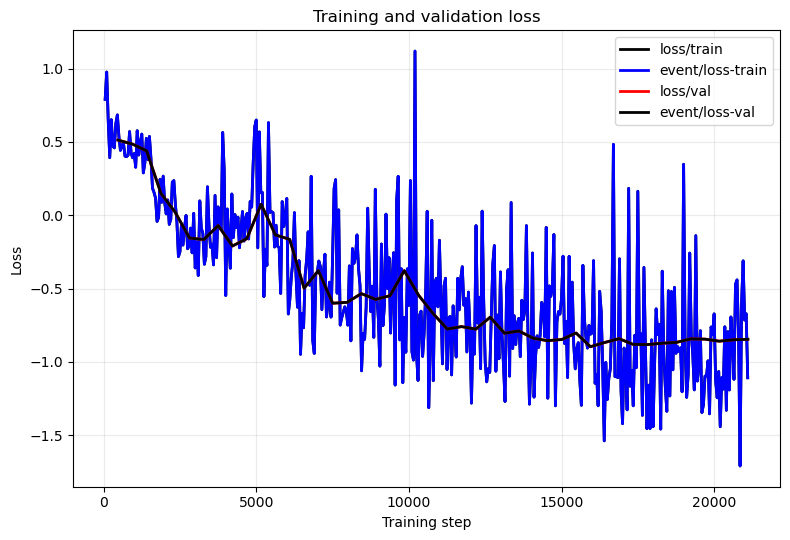

Saved: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/loss_curves.png


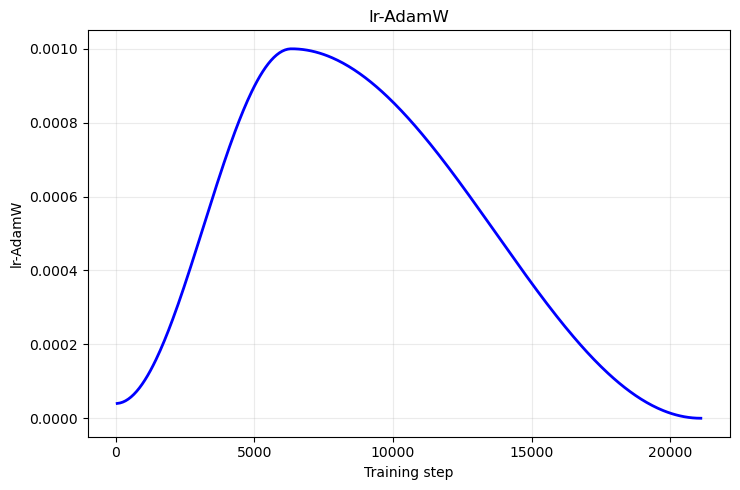

Saved: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/lr-AdamW.png


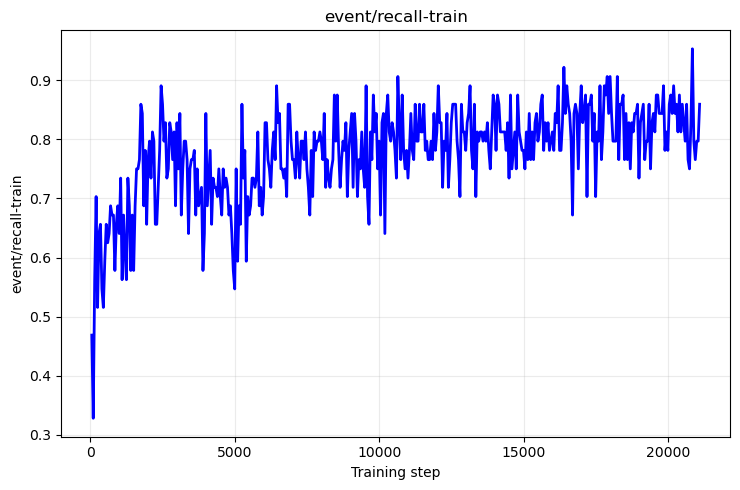

Saved: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/event_recall-train.png


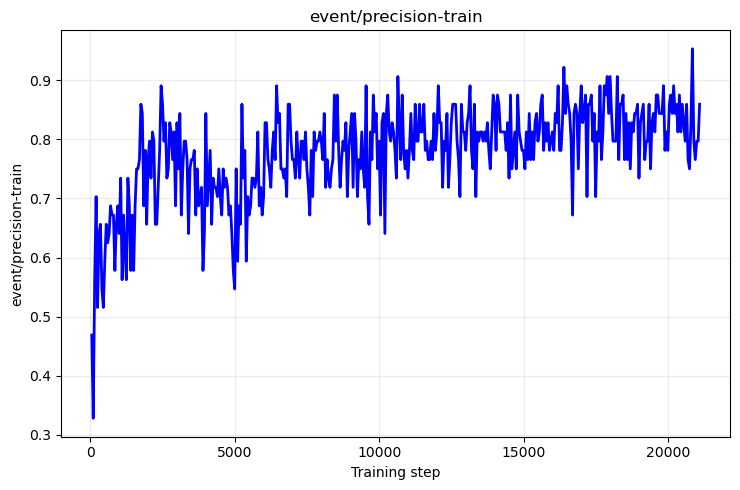

Saved: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/event_precision-train.png


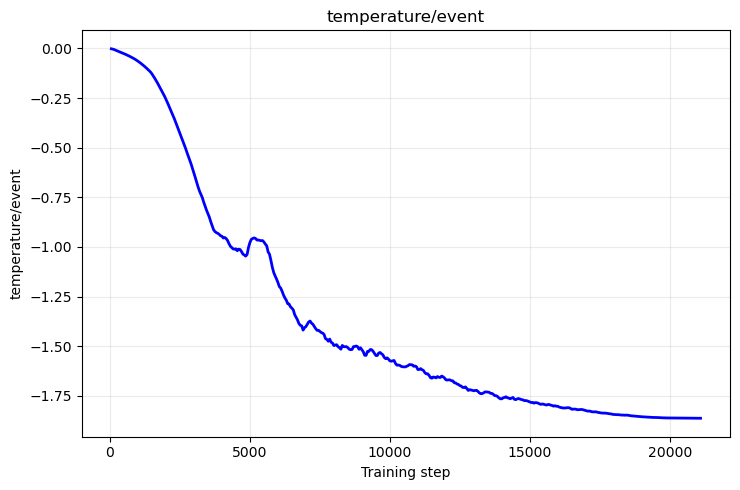

Saved: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/temperature_event.png


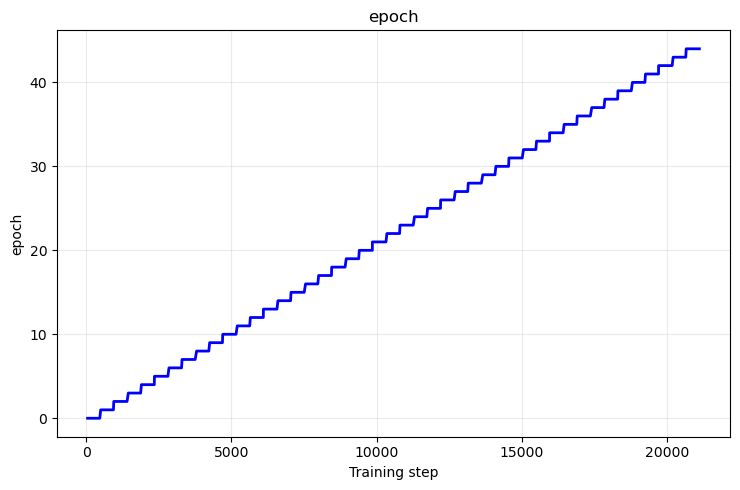

Saved: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/epoch.png


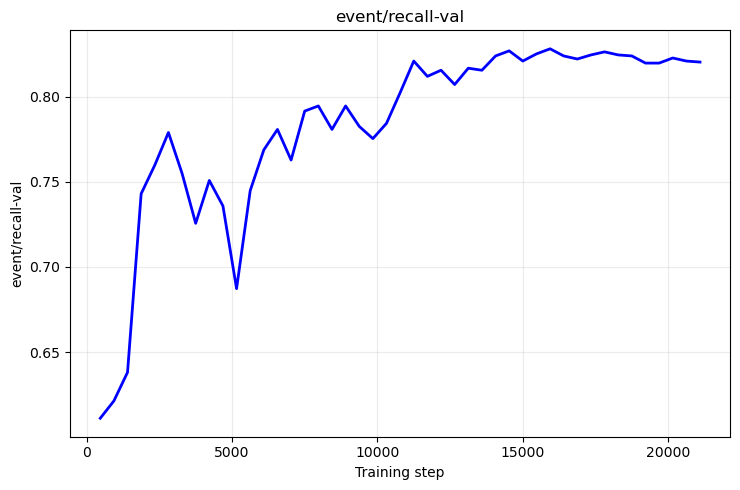

Saved: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/event_recall-val.png


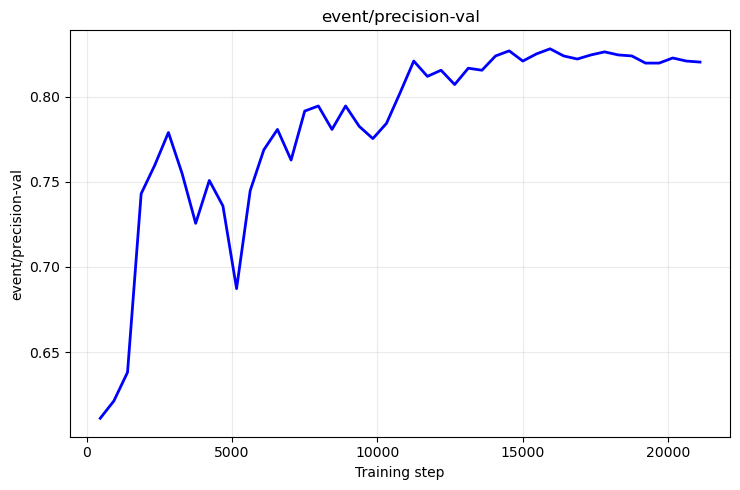

Saved: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/event_precision-val.png

All scalar plots and CSV files saved under:
/home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots


In [11]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = RUN_DIR / "exported_tensorboard_plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

scalar_tags = tags.get("scalars", [])

if not scalar_tags:
    raise RuntimeError("No scalar data were found in the TensorBoard log.")


def safe_filename(text):
    """Convert a TensorBoard tag into a safe filename."""
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", text).strip("_")


def get_scalar_dataframe(tag):
    """Return wall time, training step and value for one scalar tag."""
    events = ea.Scalars(tag)

    return pd.DataFrame({
        "wall_time": [event.wall_time for event in events],
        "step": [event.step for event in events],
        "value": [event.value for event in events],
    })


# Save every scalar history to CSV
for tag in scalar_tags:
    scalar_df = get_scalar_dataframe(tag)

    csv_file = OUTPUT_DIR / f"{safe_filename(tag)}.csv"
    scalar_df.to_csv(csv_file, index=False)


# ----------------------------------------------------------
# Combined loss plot
# ----------------------------------------------------------

loss_tags = [
    tag for tag in scalar_tags
    if "loss" in tag.lower()
]

print("Loss tags found:")
for tag in loss_tags:
    print(" ", tag)

if loss_tags:
    fig, ax = plt.subplots(figsize=(8.0, 5.5))

    line_colors = ["black", "blue", "red"]

    for index, tag in enumerate(loss_tags):
        scalar_df = get_scalar_dataframe(tag)

        # Sort because TensorBoard records are not always returned in order
        scalar_df = scalar_df.sort_values("step")

        ax.plot(
            scalar_df["step"],
            scalar_df["value"],
            linewidth=2,
            color=line_colors[index % len(line_colors)],
            label=tag,
        )

    ax.set_xlabel("Training step")
    ax.set_ylabel("Loss")
    ax.set_title("Training and validation loss")
    ax.legend()
    ax.grid(alpha=0.25)

    fig.tight_layout()

    loss_file = OUTPUT_DIR / "loss_curves.png"
    fig.savefig(loss_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", loss_file)

else:
    print("No scalar tag containing 'loss' was found.")


# ----------------------------------------------------------
# Plot every non-loss scalar separately
# ----------------------------------------------------------

other_scalar_tags = [
    tag for tag in scalar_tags
    if tag not in loss_tags
]

for tag in other_scalar_tags:
    scalar_df = get_scalar_dataframe(tag).sort_values("step")

    fig, ax = plt.subplots(figsize=(7.5, 5.0))

    ax.plot(
        scalar_df["step"],
        scalar_df["value"],
        linewidth=2,
        color="blue",
    )

    ax.set_xlabel("Training step")
    ax.set_ylabel(tag)
    ax.set_title(tag)
    ax.grid(alpha=0.25)

    fig.tight_layout()

    output_file = OUTPUT_DIR / f"{safe_filename(tag)}.png"
    fig.savefig(output_file, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_file)

print("\nAll scalar plots and CSV files saved under:")
print(OUTPUT_DIR)

In [12]:
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

IMAGE_DIR = OUTPUT_DIR / "images"
HISTOGRAM_DIR = OUTPUT_DIR / "histograms"

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
HISTOGRAM_DIR.mkdir(parents=True, exist_ok=True)


# ----------------------------------------------------------
# Export TensorBoard images
# ----------------------------------------------------------

image_tags = tags.get("images", [])

if image_tags:
    print("Exporting TensorBoard images...")

    for tag in image_tags:
        image_events = ea.Images(tag)

        tag_directory = IMAGE_DIR / safe_filename(tag)
        tag_directory.mkdir(parents=True, exist_ok=True)

        for image_number, image_event in enumerate(image_events):
            image = Image.open(
                io.BytesIO(image_event.encoded_image_string)
            )

            output_file = (
                tag_directory
                / f"step_{image_event.step:08d}_{image_number:03d}.png"
            )

            image.save(output_file)

        # Save the final image again with a simple filename
        final_event = image_events[-1]
        final_image = Image.open(
            io.BytesIO(final_event.encoded_image_string)
        )

        final_file = IMAGE_DIR / f"{safe_filename(tag)}_final.png"
        final_image.save(final_file)

        print(
            f"  {tag}: {len(image_events)} images; "
            f"final image saved as {final_file.name}"
        )

else:
    print("No TensorBoard image summaries were found.")


# ----------------------------------------------------------
# Export true TensorBoard histogram summaries
# ----------------------------------------------------------

histogram_tags = tags.get("histograms", [])

if histogram_tags:
    print("\nExporting final TensorBoard histograms...")

    for tag in histogram_tags:
        histogram_events = ea.Histograms(tag)

        if not histogram_events:
            continue

        # Use the final recorded histogram
        histogram_event = histogram_events[-1]
        histogram = histogram_event.histogram_value

        bucket_limits = np.asarray(
            histogram.bucket_limit,
            dtype=float,
        )

        bucket_counts = np.asarray(
            histogram.bucket,
            dtype=float,
        )

        # Remove TensorBoard overflow boundaries
        valid = (
            np.isfinite(bucket_limits)
            & np.isfinite(bucket_counts)
            & (np.abs(bucket_limits) < 1.0e30)
        )

        bucket_limits = bucket_limits[valid]
        bucket_counts = bucket_counts[valid]

        if len(bucket_limits) == 0:
            print(f"  Skipping empty histogram: {tag}")
            continue

        fig, ax = plt.subplots(figsize=(7.5, 5.0))

        ax.step(
            bucket_limits,
            bucket_counts,
            where="post",
            linewidth=1.8,
            color="blue",
        )

        ax.set_xlabel("Histogram bucket upper boundary")
        ax.set_ylabel("Count")
        ax.set_title(f"{tag} — final logged step {histogram_event.step}")
        ax.grid(alpha=0.25)

        fig.tight_layout()

        output_file = (
            HISTOGRAM_DIR
            / f"{safe_filename(tag)}_final.png"
        )

        fig.savefig(output_file, dpi=300, bbox_inches="tight")
        plt.close(fig)

        print("  Saved:", output_file)

else:
    print(
        "\nNo true histogram summaries were logged. "
        "This is not an error; the training run may have logged only "
        "scalars and images."
    )


print("\nExport complete.")
print("Scalar plots :", OUTPUT_DIR)
print("Images       :", IMAGE_DIR)
print("Histograms   :", HISTOGRAM_DIR)

Exporting TensorBoard images...
  event/recall-matrix-val: 46 images; final image saved as event_recall-matrix-val_final.png
  event/precision-matrix-val: 46 images; final image saved as event_precision-matrix-val_final.png

No true histogram summaries were logged. This is not an error; the training run may have logged only scalars and images.

Export complete.
Scalar plots : /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots
Images       : /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/images
Histograms   : /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int32/version_0/exported_tensorboard_plots/histograms
